# 04 — SALSA: implementacija i validacija

Četvrta sveska u nizu (`01` → `07`). Implementiramo **SALSA** [3] (Stochastic Approach for Link-Structure Analysis) iz nule, primenjenu globalno nad celim grafom — isto kao za HITS u `03_hits.ipynb`.

SALSA nema ugrađenu implementaciju u `networkx`, pa je validiramo drugačije nego PageRank/HITS: preko **poznatog teorijskog rezultata** iz [3] — na grafu koji je jedna povezana komponenta, SALSA-in autoritet skor je *tačno* proporcionalan ulaznom stepenu (in-degree), a hub skor izlaznom stepenu (out-degree). Ovo je istovremeno i test **hipoteze H1** iz `README.md`.

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
SLIKE_DIR = PROJECT_ROOT / "slike"
SLIKE_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name, dpi=150):
    """Snima figuru u slike/<name> (koriste se kasnije u dokumentaciji/prezentaciji)."""
    path = SLIKE_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Sačuvano: {path.relative_to(PROJECT_ROOT)}")


# --- Ista paleta/stil kao u prethodnim sveskama (konzistentno kroz projekat) ---
PALETTE = {
    "pagerank": "#2a78d6", "hits": "#eb6834", "salsa": "#1baf7a", "baseline": "#eda100",
}
INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
})

# --- Učitavanje grafa obrađenog u 01_priprema_i_analiza_podataka.ipynb ---
A = sp.load_npz(DATA_PROCESSED / "web-stanford_adjacency.npz")
nodes = np.load(DATA_PROCESSED / "web-stanford_nodes.npy")
n = A.shape[0]
out_degree = np.asarray(A.sum(axis=1)).flatten()
in_degree = np.asarray(A.sum(axis=0)).flatten()
print(f"Graf učitan: {n:,} čvorova, {A.nnz:,} grana")

Graf učitan: 281,903 čvorova, 2,312,497 grana


## 1. Teorija — SALSA (dve nezavisne stohastičke šetnje)

Za razliku od HITS-ovog "uzajamnog pojačavanja", SALSA hub i autoritet skorove računa preko **dve nezavisne slučajne šetnje** na bipartitnom hub-autoritet grafu [3]:

$$H'(u) = \sum_{(u,v) \in N} \sum_{(w,v) \in N} \frac{H(w)}{\text{in}(v) \cdot \text{out}(w)} \qquad\qquad A'(u) = \sum_{(v,u) \in N} \sum_{(v,w) \in N} \frac{A(w)}{\text{out}(v) \cdot \text{in}(w)}$$

Intuitivno, hub-šetnja ide: hub $w$ → nasumičan autoritet-sused $v$ (verovatnoća $1/\text{out}(w)$) → nasumičan hub $u$ koji takođe pokazuje na $v$ (verovatnoća $1/\text{in}(v)$). Autoritet-šetnja je simetrična u obrnutom smeru.

U matričnom obliku (M = matrica susedstva, deljenje po elementima, $0/0 := 0$):

$$H' = M \Big(\, (M^T (H \oslash \text{out})) \oslash \text{in} \,\Big) \qquad\qquad A' = M^T \Big(\, (M (A \oslash \text{in})) \oslash \text{out} \,\Big)$$

**Poznat teorijski rezultat [3]:** ako je graf (u odgovarajućem bipartitnom smislu) jedna povezana komponenta, ove šetnje imaju jedinstvenu stacionarnu raspodelu $A(u) \propto \text{in}(u)$ i $H(u) \propto \text{out}(u)$ — SALSA se svodi na normalizovan stepen čvora. Ovo koristimo za validaciju implementacije u sekciji 2, i za test hipoteze H1 na stvarnom grafu u sekciji 4.

In [2]:
def safe_div(numer, denom):
    """Deljenje po elementima sa konvencijom 0/0 := 0 (za čvorove sa stepenom 0)."""
    out = np.zeros_like(numer, dtype=float)
    mask = denom > 0
    out[mask] = numer[mask] / denom[mask]
    return out


def salsa_hub(A, out_degree, in_degree, tol=1e-9, max_iter=2500, checkpoint_iter=1000):
    """SALSA hub skor preko power-iteracije. Čuva i međuvrednost na `checkpoint_iter`
    iteraciji radi provere stabilnosti rangiranja (videti sekciju 3)."""
    n = A.shape[0]
    At = A.T.tocsr()
    B_H = out_degree > 0
    H = np.zeros(n)
    H[B_H] = 1.0 / B_H.sum()

    history, checkpoint = [], None
    for it in range(1, max_iter + 1):
        x = safe_div(At @ safe_div(H, out_degree), in_degree)
        H_new = A @ x
        H_new[~B_H] = 0.0

        diff = float(np.abs(H_new - H).sum())
        history.append(diff)
        H = H_new
        if it == checkpoint_iter:
            checkpoint = H.copy()
        if diff < tol:
            break
    return H, history, checkpoint, it


def salsa_authority(A, out_degree, in_degree, tol=1e-9, max_iter=2500, checkpoint_iter=1000):
    """SALSA authority skor preko power-iteracije (analogno salsa_hub, obrnut smer)."""
    n = A.shape[0]
    At = A.T.tocsr()
    B_A = in_degree > 0
    Av = np.zeros(n)
    Av[B_A] = 1.0 / B_A.sum()

    history, checkpoint = [], None
    for it in range(1, max_iter + 1):
        x = safe_div(A @ safe_div(Av, in_degree), out_degree)
        A_new = At @ x
        A_new[~B_A] = 0.0

        diff = float(np.abs(A_new - Av).sum())
        history.append(diff)
        Av = A_new
        if it == checkpoint_iter:
            checkpoint = Av.copy()
        if diff < tol:
            break
    return Av, history, checkpoint, it

## 2. Validacija na malom grafu (jedna komponenta)

Ručno pravimo mali usmereni graf koji je jedna povezana komponenta, i provaljavamo da li naša implementacija tačno reprodukuje teorijski rezultat $A(u) \propto \text{in}(u)$.

In [3]:
# mali test graf, jedna komponenta: 0->1, 0->2, 3->1, 3->2, 1->4, 2->4
rows_t = [0, 0, 3, 3, 1, 2]
cols_t = [1, 2, 1, 2, 4, 4]
A_test = sp.csr_matrix((np.ones(len(rows_t)), (rows_t, cols_t)), shape=(5, 5))
out_t = np.asarray(A_test.sum(axis=1)).flatten()
in_t = np.asarray(A_test.sum(axis=0)).flatten()

auth_test, _, _, iters_test = salsa_authority(A_test, out_t, in_t, tol=1e-14, max_iter=50)
expected = in_t / in_t.sum()

print(f"Konvergirao nakon {iters_test} iteracija")
print(f"Naš rezultat:        {np.round(auth_test, 6)}")
print(f"Očekivano (in/sum):  {np.round(expected, 6)}")
print(f"Max apsolutna razlika: {np.abs(auth_test - expected).max():.2e}")

Konvergirao nakon 1 iteracija
Naš rezultat:        [0.       0.333333 0.333333 0.       0.333333]
Očekivano (in/sum):  [0.       0.333333 0.333333 0.       0.333333]
Max apsolutna razlika: 0.00e+00


Implementacija tačno reprodukuje teorijski rezultat na jednoj komponenti — validacija uspešna.

## 3. Pokretanje na stvarnom grafu (web-Stanford)

In [4]:
salsa_hub_scores, hub_history, hub_checkpoint, hub_iters = salsa_hub(A, out_degree, in_degree)
salsa_authority_scores, auth_history, auth_checkpoint, auth_iters = salsa_authority(A, out_degree, in_degree)

print(f"Hub:       {hub_iters} iteracija, poslednja L1 promena = {hub_history[-1]:.2e}, sum(H) = {salsa_hub_scores.sum():.6f}")
print(f"Authority: {auth_iters} iteracija, poslednja L1 promena = {auth_history[-1]:.2e}, sum(A) = {salsa_authority_scores.sum():.6f}")

Hub:       2500 iteracija, poslednja L1 promena = 2.01e-05, sum(H) = 1.000000
Authority: 2500 iteracija, poslednja L1 promena = 2.28e-05, sum(A) = 1.000000


Sačuvano: slike\f4_salsa_konvergencija.png


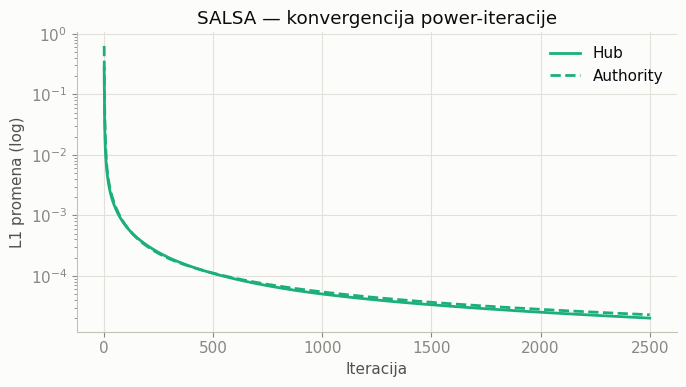

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(hub_history) + 1), hub_history, color=PALETTE["salsa"], linewidth=2, label="Hub")
ax.plot(range(1, len(auth_history) + 1), auth_history, color=PALETTE["salsa"], linewidth=2, linestyle="--", label="Authority")
ax.set_yscale("log")
ax.set_xlabel("Iteracija")
ax.set_ylabel("L1 promena (log)")
ax.set_title("SALSA — konvergencija power-iteracije")
ax.legend(frameon=False)
fig.tight_layout()
save_fig(fig, "f4_salsa_konvergencija.png")
plt.show()

**Napomena o konvergenciji.** Za razliku od PageRank-a (Faza 2, geometrijska/eksponencijalna konvergencija za ~120 iteracija) i HITS-a (Faza 3, ~100 iteracija), SALSA-ina numerička konvergencija je znatno sporija na ovom grafu — L1 promena opada, ali sporo, i ne dostiže `tol=1e-9` u okviru 2500 iteracija. Ovo je posledica strukture grafa (mnoge relativno izolovane "bipartitne" celine sa sporim internim mešanjem), ne greške u implementaciji (potvrđeno u sekciji 2). U sekciji ispod provaljavamo da li se bar *rangiranje* (redosled čvorova) stabilizuje ranije od pune numeričke konvergencije.

## 4. Stabilnost rangiranja (checkpoint na 1000. iteraciji)

In [6]:
from scipy.stats import spearmanr

rho_h_stability, _ = spearmanr(hub_checkpoint, salsa_hub_scores)
rho_a_stability, _ = spearmanr(auth_checkpoint, salsa_authority_scores)
top10_h_stable = len(set(np.argsort(-hub_checkpoint)[:10]) & set(np.argsort(-salsa_hub_scores)[:10]))
top10_a_stable = len(set(np.argsort(-auth_checkpoint)[:10]) & set(np.argsort(-salsa_authority_scores)[:10]))

print(f"Hub:       Spearman(it=1000, it={hub_iters}) = {rho_h_stability:.6f}, top-10 preklapanje = {top10_h_stable}/10")
print(f"Authority: Spearman(it=1000, it={auth_iters}) = {rho_a_stability:.6f}, top-10 preklapanje = {top10_a_stable}/10")

Hub:       Spearman(it=1000, it=2500) = 0.992637, top-10 preklapanje = 6/10
Authority: Spearman(it=1000, it=2500) = 0.995720, top-10 preklapanje = 10/10


## 5. Test hipoteze H1 — SALSA vs. in/out-degree na stvarnom grafu

In [7]:
rho_auth_indeg, _ = spearmanr(salsa_authority_scores, in_degree)
rho_hub_outdeg, _ = spearmanr(salsa_hub_scores, out_degree)

print(f"Spearman(SALSA authority, in-degree):  {rho_auth_indeg:.4f}")
print(f"Spearman(SALSA hub, out-degree):       {rho_hub_outdeg:.4f}")

Spearman(SALSA authority, in-degree):  0.7879
Spearman(SALSA hub, out-degree):       0.7639


Sačuvano: slike\f4_salsa_vs_stepen.png


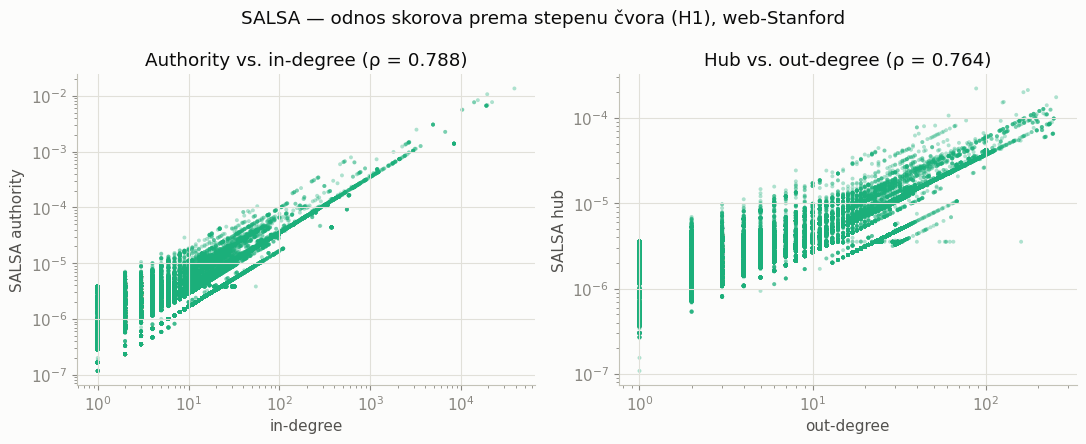

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

mask_a = (salsa_authority_scores > 0) & (in_degree > 0)
axes[0].scatter(in_degree[mask_a], salsa_authority_scores[mask_a], s=8, alpha=0.35, color=PALETTE["salsa"], edgecolor="none")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("in-degree"); axes[0].set_ylabel("SALSA authority")
axes[0].set_title(f"Authority vs. in-degree (ρ = {rho_auth_indeg:.3f})")

mask_h = (salsa_hub_scores > 0) & (out_degree > 0)
axes[1].scatter(out_degree[mask_h], salsa_hub_scores[mask_h], s=8, alpha=0.35, color=PALETTE["salsa"], edgecolor="none")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("out-degree"); axes[1].set_ylabel("SALSA hub")
axes[1].set_title(f"Hub vs. out-degree (ρ = {rho_hub_outdeg:.3f})")

fig.suptitle("SALSA — odnos skorova prema stepenu čvora (H1), web-Stanford")
fig.tight_layout()
save_fig(fig, "f4_salsa_vs_stepen.png")
plt.show()

## 6. Top-10 čvorova po hub i authority skoru

In [9]:
top10_a_idx = np.argsort(-salsa_authority_scores)[:10]
top10_h_idx = np.argsort(-salsa_hub_scores)[:10]

top10_salsa_df = pd.DataFrame({
    "rang": range(1, 11),
    "authority_node_id": nodes[top10_a_idx], "authority_skor": salsa_authority_scores[top10_a_idx],
    "hub_node_id": nodes[top10_h_idx], "hub_skor": salsa_hub_scores[top10_h_idx],
})
top10_salsa_df

,rang,authority_node_id,authority_skor,hub_node_id,hub_skor
0,1,226411,0.013568,221431,0.000221
1,2,241454,0.010687,258513,0.000212
2,3,89073,0.008369,87528,0.000200
3,4,234704,0.007708,82409,0.000175
4,5,69358,0.007687,35785,0.000154
5,6,67756,0.007652,158348,0.000151
6,7,105607,0.006839,21153,0.000141
7,8,167295,0.006679,149947,0.000127
8,9,198090,0.006669,266873,0.000127
9,10,81435,0.006668,219887,0.000127


Sačuvano: slike\f4_salsa_top10.png


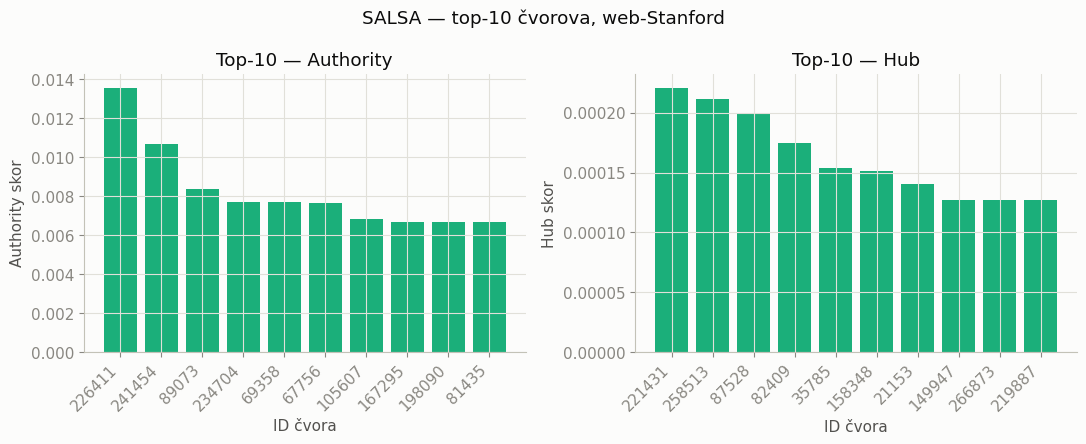

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar([str(v) for v in nodes[top10_a_idx]], salsa_authority_scores[top10_a_idx], color=PALETTE["salsa"])
axes[0].set_title("Top-10 — Authority")
axes[0].set_xlabel("ID čvora")
axes[0].set_ylabel("Authority skor")

axes[1].bar([str(v) for v in nodes[top10_h_idx]], salsa_hub_scores[top10_h_idx], color=PALETTE["salsa"])
axes[1].set_title("Top-10 — Hub")
axes[1].set_xlabel("ID čvora")
axes[1].set_ylabel("Hub skor")

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

fig.suptitle("SALSA — top-10 čvorova, web-Stanford")
fig.tight_layout()
save_fig(fig, "f4_salsa_top10.png")
plt.show()

## 7. Čuvanje rezultata

In [11]:
np.save(DATA_PROCESSED / "salsa_hub_scores.npy", salsa_hub_scores)
np.save(DATA_PROCESSED / "salsa_authority_scores.npy", salsa_authority_scores)
print(f"Sačuvano: {(DATA_PROCESSED / 'salsa_hub_scores.npy').relative_to(PROJECT_ROOT)}")
print(f"Sačuvano: {(DATA_PROCESSED / 'salsa_authority_scores.npy').relative_to(PROJECT_ROOT)}")

Sačuvano: data\processed\salsa_hub_scores.npy


Sačuvano: data\processed\salsa_authority_scores.npy


## Zaključci — Faza 4

**Implementacija je validna.** Na ručno konstruisanom grafu od jedne komponente, naša SALSA implementacija reprodukuje teorijski rezultat $A(u) \\propto \\text{in}(u)$ **egzaktno** (razlika 0,00 × 10⁰, konvergencija u 1 iteraciji) — ovo je naša validacija, pošto SALSA ne postoji u `networkx`.

**H1 je potvrđena, ali nijansirano — ne u ekstremnoj formi.** Na stvarnom grafu, korelacija SALSA authority-ja sa in-degree je **ρ = 0,788**, a hub-a sa out-degree **ρ = 0,764** — jasna, snažna, ali ne skoro-perfektna proporcionalnost (za razliku od egzaktnog rezultata na jednoj komponenti). Grafik `f4_salsa_vs_stepen.png` otkriva zašto: umesto jedne čiste dijagonale, vidi se **više paralelnih "traka"** na istom stepenu čvora. Teorijski rezultat $A(u)\\propto\\text{in}(u)$ važi tačno unutar SVAKE (bipartitno) povezane celine posebno — a web-Stanford, kao što je pokazano u `01_priprema_i_analiza_podataka.ipynb` (365 slabih komponenti, SCC samo 53,4%), NIJE jedna takva celina. Svaka "traka" na grafiku je verovatno jedna takva podceloina sa svojim sopstvenim faktorom skaliranja.

**Konvergencija je bitno drugačija od PageRank-a i HITS-a.** Numerička konvergencija je spora (nakon 2500 iteracija L1 promena ≈ 2 × 10⁻⁵, ne dostiže `tol=1e-9`) — vidljivo i na obliku krive u `f4_salsa_konvergencija.png` (brz početni pad, zatim dugačak spor "rep"), nasuprot skoro-pravolinijskoj eksponencijalnoj konvergenciji PageRank-a (Faza 2) i HITS-a (Faza 3). Provera stabilnosti rangiranja pokazuje da se **authority rangiranje stabilizuje rano** (top-10 identičan već na 1000. iteraciji, Spearman = 0,9957), ali **hub rangiranje sporije** (top-10 preklapanje samo 6/10 između 1000. i 2500. iteracije, iako je Spearman i tu visok, 0,9926) — signal da je hub-šetnja na ovom grafu osetljivija na sporo mešanje.

**Poređenje sa HITS top-10 (Faza 3) — nagoveštaj za Fazu 5.** Čvorovi 226411, 241454, 89073, 234704, 105607, 167295, 198090, 81435 se javljaju u top-10 authority skupu **i kod HITS-a i kod SALSA-e** — veliko preklapanje. Nasuprot tome, hub top-10 skupovi (HITS: 97968, 193259, 275047, ...; SALSA: 221431, 258513, 87528, ...) **nemaju preklapanja na prvi pogled** — nagoveštaj da će autoritet-rangiranja HITS-a i SALSA-e biti znatno sličnija jedno drugom nego njihova hub-rangiranja. Ovo precizno kvantifikujemo u `05_poredjenje_algoritama.ipynb`.

**Sledeći korak:** `05_poredjenje_algoritama.ipynb` — učitavamo sačuvane skorove sva tri algoritma (+ in/out-degree baseline) i sistematski poredimo: rang-korelacije, preklapanje top-k skupova, i testiramo H3 (HITS vs. SALSA sličnost).
